In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from scripts.training.preprocessed import FinalData

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap

In [ ]:
os.chdir("..")

final_data = FinalData(
    data_dir="data",
    encoder_dir="encoders",
    save_report_path="report.json",
    verbose=True,
    last_month=34
)

train_df, test_df = final_data.get_final_data()

Обнаружено 4023 записей с дублирующимися названиями после чистки!
Примеры дубликатов:
    item_id                      item_name
12       12  МИХЕЙ И ДЖУМАНДЖИ Сука любовь
30       30        007 КООРДИНАТЫ СКАЙФОЛЛ
31       31        007 КООРДИНАТЫ СКАЙФОЛЛ
32       32                             11
33       33                             11
35       35                  10 ЛЕТ СПУСТЯ
36       36                  10 ЛЕТ СПУСТЯ
37       37                  10 ЛЕТ СПУСТЯ
71       71            11 ДРУЗЕЙ ОУШЕНА WB
72       72            11 ДРУЗЕЙ ОУШЕНА WB

Найдено 1657 уникальных названий, которые повторяются:
                       item_name  count
0        007 КООРДИНАТЫ СКАЙФОЛЛ      2
1                  10 ЛЕТ СПУСТЯ      3
2                             11      2
3            11 ДРУЗЕЙ ОУШЕНА WB      2
4            12 ДРУЗЕЙ ОУШЕНА WB      2
5                 12 ЛЕТ РАБСТВА      2
6                      127 ЧАСОВ      3
7                   12ДВЕНАДЦАТЬ      2
8            13 ДРУЗЕЙ ОУ

In [5]:
model = lgb.Booster(model_file="models/regressor.txt")

In [16]:
train_sample = train_df.sample(n=1000, random_state=42)
X_sample = train_sample.drop("item_cnt_month", axis=1)

In [17]:
explainer = shap.TreeExplainer(model)

In [20]:
shap_values = explainer.shap_values(X_sample)

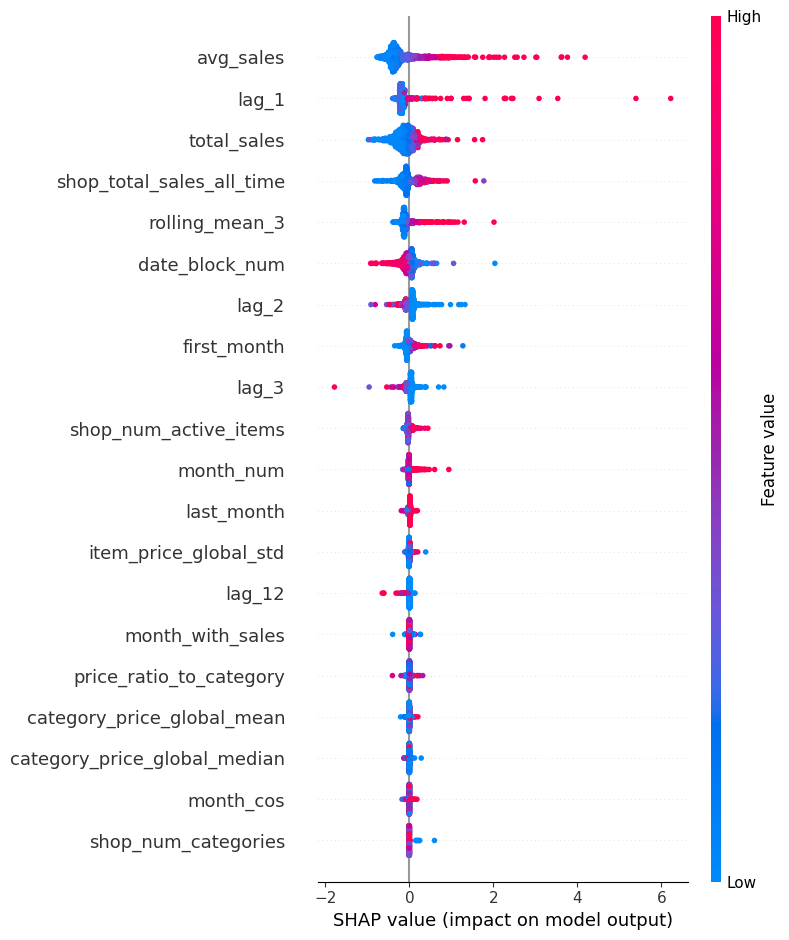

In [21]:
shap.summary_plot(shap_values, X_sample)

- Фичи расположены в порядке убыванию по важности
- Красный справа значит, что между таргетом и признаком прямая зависимость(чем выше значение признака, тем больше предикт)
- Красный слева значит, что между таргетом и признакома обратная зваисимость(чем выше значение признака, тем меньше предикт)
- Точек много, так как показан кажыдй объект из сабсета(каждая строчка)


In [ ]:
sns.set_theme(style="whitegrid", palette="viridis")

### Тут просто взяли 1 строку из сабсета

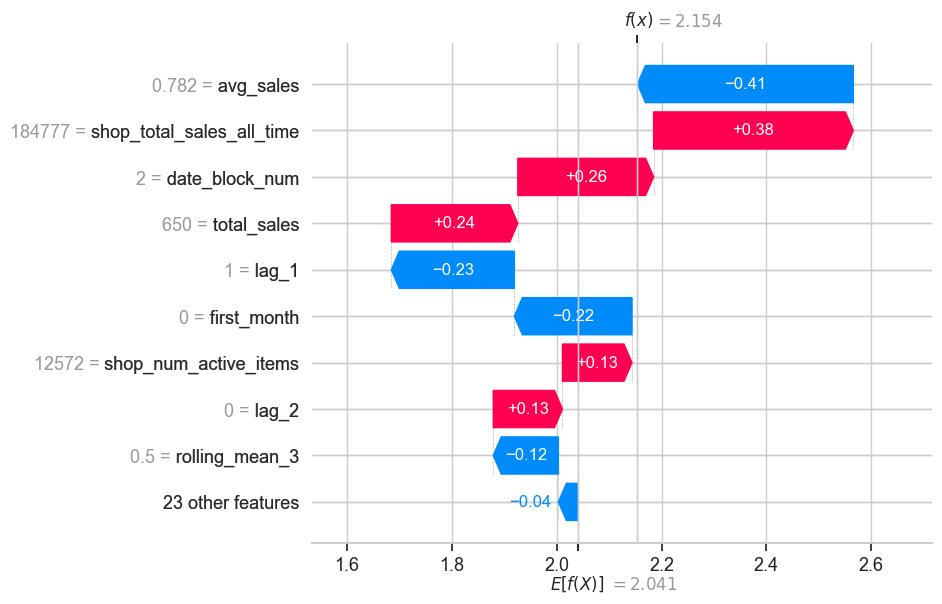

<Figure size 640x480 with 0 Axes>

In [ ]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=X_sample.columns
    )
)

plt.tight_layout()
plt.show()

- E[f(X)] и есть та самая констнта(среднее), то есть моделька предскажет это даже об объекте про который ничего не знает
- f(x) итоговый выход с модели
- крансые стрелки увеличивают значение выхода
- синие стрелки умнеьшают значения выхода
- около признаком(слева) пишется их реально значение для данного объекта

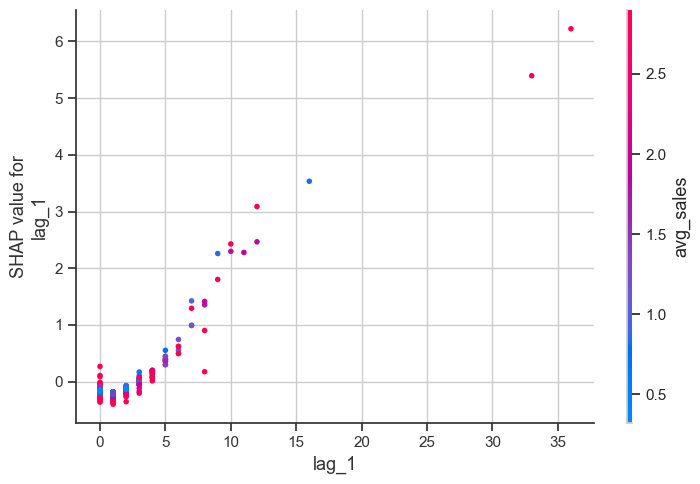

In [25]:
shap.dependence_plot("lag_1", shap_values, X_sample, show=False)
sns.despine()
plt.tight_layout()
plt.show()

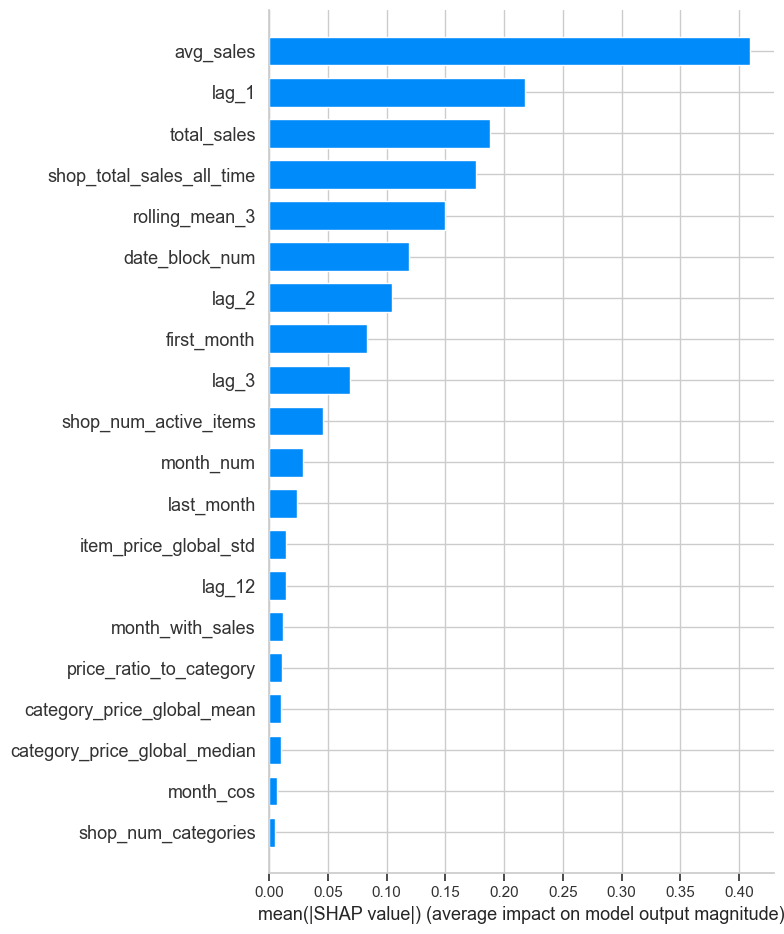

In [26]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
sns.despine()
plt.tight_layout()
plt.show()